DVLSensor rate 20 is not a factor of ticks_per_sec 30, rounding to 30

========== EKF PERFORMANCE (IMU + DVL, WITH CONTROL) ==========
Simulation duration: 39.97 s

Position RMSE:
  Total  : 0.153 m
  x-axis : 0.145 m
  y-axis : 0.048 m
  z-axis : 0.005 m

Velocity RMSE:
  Total  : 0.070 m/s
  x-axis : 0.052 m/s
  y-axis : 0.045 m/s
  z-axis : 0.013 m/s

Final position error norm: 0.181 m



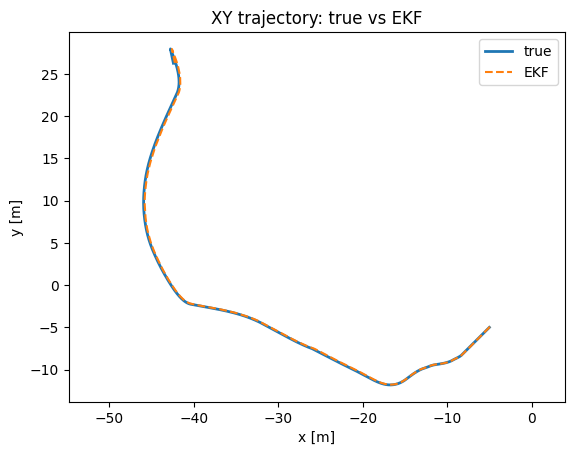

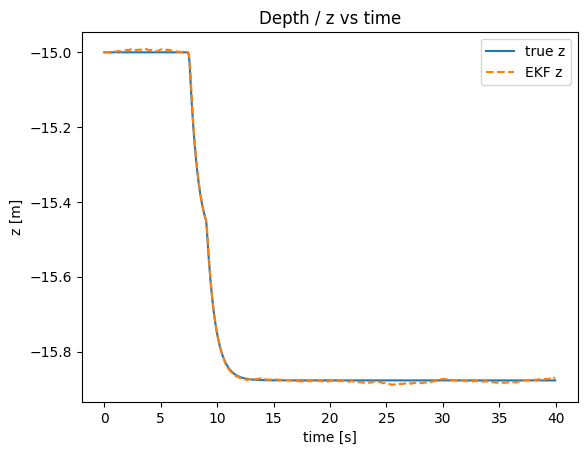

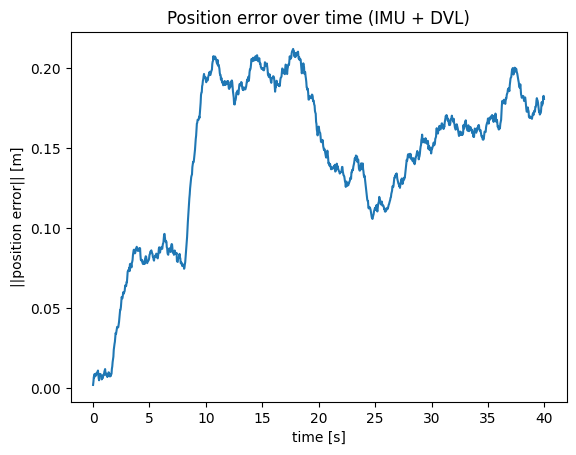

In [3]:
"""
EKF FUSION OF IMU + DVL IN HOLOOCEAN, WITH KEYBOARD CONTROL
-----------------------------------------------------------

Features:
- AUV is controlled from keyboard (thruster commands).
- State is estimated with EKF:
    x = [x, y, z, vx, vy, vz]^T (world frame)
- IMU (with bias) provides acceleration -> prediction step.
- DVL provides velocity -> linear update step.
- PoseSensor provides:
    - Ground truth position
    - Orientation (for transforming IMU/DVL to world frame)
- At the end, the script prints RMSE metrics and plots trajectories & errors.

Keyboard mapping (same as your original code):
    i / k : forward / backward (all 4 main thrusters)
    j / l : yaw left / right
    w / s : up / down (vertical thrusters)
    a / d : roll left / right

Hold keys to apply force; release to stop.
"""

import holoocean
import numpy as np
import matplotlib.pyplot as plt
from pynput import keyboard


# ============================================================
# TUNABLE PARAMETERS
# ============================================================

# Scenario & agent configuration
SCENARIO_NAME = "blue_rov"   # <-- set this to your scenario name
AUV_NAME = "auv"           # <-- set to your agent name ("auv", "auv0", etc.)

# Simulation timing
DEFAULT_TICKS_PER_SEC = 30
SIM_DURATION_SEC = 40.0     # total simulation length in seconds

# Keyboard/thruster control
BASE_THRUSTER_FORCE = 10.0  # magnitude of command applied by each key

# Gravity in WORLD frame (based on your IMU+Pose sample)
GRAVITY_WORLD = np.array([0.0, 0.0, 9.81])

# EKF process noise (Q)
Q_POS_STD = 0.02   # std dev for position noise per step (m)
Q_VEL_STD = 0.2    # std dev for velocity noise per step (m/s)

# EKF initial covariance (P)
P_POS_STD_INIT = 1.0   # initial pos uncertainty (m)
P_VEL_STD_INIT = 1.0   # initial vel uncertainty (m/s)

# DVL measurement noise (R)
DVL_VEL_STD = 0.05     # std dev for each velocity component (m/s)

# Use DVL update? (set False to see IMU-only behaviour)
USE_DVL_UPDATE = True


# ============================================================
# EKF CLASS
# ============================================================

class EKF:
    """
    Simple 6D EKF:

        x = [x, y, z, vx, vy, vz]^T  (world frame)
    """

    def __init__(self, dt):
        self.dt = dt

        # State
        self.x = np.zeros(6)

        # Covariance
        self.P = np.diag([
            P_POS_STD_INIT**2,
            P_POS_STD_INIT**2,
            P_POS_STD_INIT**2,
            P_VEL_STD_INIT**2,
            P_VEL_STD_INIT**2,
            P_VEL_STD_INIT**2,
        ])

        # Process noise
        self.Q = np.diag([
            Q_POS_STD**2,
            Q_POS_STD**2,
            Q_POS_STD**2,
            Q_VEL_STD**2,
            Q_VEL_STD**2,
            Q_VEL_STD**2,
        ])

    def predict(self, a_world):
        """Prediction using world-frame acceleration (gravity already removed)."""
        dt = self.dt

        F = np.eye(6)
        F[0, 3] = dt
        F[1, 4] = dt
        F[2, 5] = dt

        B = np.zeros((6, 3))
        B[3, 0] = dt
        B[4, 1] = dt
        B[5, 2] = dt

        a_world = np.asarray(a_world).reshape(3,)

        self.x = F @ self.x + B @ a_world
        self.P = F @ self.P @ F.T + self.Q

    def update_linear(self, z, H, R):
        """Standard linear KF update: z = Hx + noise."""
        z = np.asarray(z).reshape(-1, 1)
        H = np.asarray(H)
        R = np.asarray(R)

        x = self.x.reshape(-1, 1)
        y = z - H @ x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = (x + K @ y).flatten()
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ H) @ self.P


# ============================================================
# KEYBOARD CONTROL
# ============================================================

# We'll keep currently pressed keys in a set (safe for add/remove).
pressed_keys = set()


def on_press(key):
    if hasattr(key, "char") and key.char is not None:
        pressed_keys.add(key.char)


def on_release(key):
    if hasattr(key, "char") and key.char is not None:
        pressed_keys.discard(key.char)


def parse_keys(keys, val):
    """
    Converts pressed keys into an 8D thruster command vector.

    This is exactly your original mapping, just using a set internally.
    """
    command = np.zeros(8)

    # forward/back
    if "i" in keys:
        command[0:4] += val
    if "k" in keys:
        command[0:4] -= val

    # yaw
    if "j" in keys:
        command[[4, 7]] += 0.25 * val
        command[[5, 6]] -= 0.25 * val
    if "l" in keys:
        command[[4, 7]] -= 0.25 * val
        command[[5, 6]] += 0.25 * val

    # vertical thrust
    if "w" in keys:
        command[4:8] += val
    if "s" in keys:
        command[4:8] -= val

    # roll
    if "a" in keys:
        command[[4, 6]] += val
        command[[5, 7]] -= val
    if "d" in keys:
        command[[4, 6]] -= val
        command[[5, 7]] += val

    return command


# Start keyboard listener in the background
listener = keyboard.Listener(on_press=on_press, on_release=on_release)
listener.start()


# ============================================================
# UTILITIES
# ============================================================

def compute_rmse(true, est):
    """Return (total_rmse, per_axis_rmse) for arrays shape (N,3)."""
    err = est - true
    mse_axis = np.mean(err**2, axis=0)
    rmse_axis = np.sqrt(mse_axis)
    mse_total = np.mean(np.sum(err**2, axis=1))
    rmse_total = np.sqrt(mse_total)
    return rmse_total, rmse_axis


# ============================================================
# MAIN EKF + CONTROL LOOP
# ============================================================

def run_ekf_with_control():
    true_positions = []
    est_positions = []
    true_velocities = []
    est_velocities = []
    times = []

    with holoocean.make(SCENARIO_NAME) as env:
        ticks_per_sec = getattr(env, "ticks_per_sec", DEFAULT_TICKS_PER_SEC)
        dt = 1.0 / float(ticks_per_sec)

        ekf = EKF(dt=dt)

        n_steps = int(SIM_DURATION_SEC * ticks_per_sec)
        prev_true_pos = None

        for k in range(n_steps):
            # 1) Apply keyboard control
            command = parse_keys(pressed_keys, BASE_THRUSTER_FORCE)
            env.act(AUV_NAME, command)

            # 2) Step environment
            state = env.tick()

            # 3) Read IMU, DVL, Pose
            imu = state[AUV_NAME]["IMUSensor"]
            dvl = state[AUV_NAME]["DVLSensor"]
            pose = state[AUV_NAME]["PoseSensor"]

            accel_meas = imu[0, :]
            accel_bias = imu[2, :] if imu.shape[0] >= 3 else np.zeros(3)
            accel_body = accel_meas - accel_bias

            T_ws = pose
            R_ws = T_ws[0:3, 0:3]   # body -> world
            true_pos = T_ws[0:3, 3]

            # 4) True velocity (for evaluation only)
            if prev_true_pos is None:
                true_vel = np.zeros(3)
            else:
                true_vel = (true_pos - prev_true_pos) / dt
            prev_true_pos = true_pos.copy()

            # 5) IMU prediction: body accel -> world, minus gravity
            a_world_raw = R_ws @ accel_body
            a_world = a_world_raw - GRAVITY_WORLD

            if k == 0:
                ekf.x[0:3] = true_pos.copy()
                ekf.x[3:6] = true_vel.copy()

            ekf.predict(a_world)

            # 6) DVL update (if enabled)
            if USE_DVL_UPDATE:
                v_body = dvl[0:3]
                v_world_meas = R_ws @ v_body

                H_dvl = np.array([
                    [0, 0, 0, 1, 0, 0],
                    [0, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 1],
                ])

                R_dvl = np.diag([
                    DVL_VEL_STD**2,
                    DVL_VEL_STD**2,
                    DVL_VEL_STD**2,
                ])

                ekf.update_linear(v_world_meas, H_dvl, R_dvl)

            # 7) Logging
            t = k * dt
            times.append(t)
            true_positions.append(true_pos.copy())
            est_positions.append(ekf.x[0:3].copy())
            true_velocities.append(true_vel.copy())
            est_velocities.append(ekf.x[3:6].copy())

    times = np.array(times)
    true_positions = np.array(true_positions)
    est_positions = np.array(est_positions)
    true_velocities = np.array(true_velocities)
    est_velocities = np.array(est_velocities)

    return times, true_positions, est_positions, true_velocities, est_velocities


def main():
    times, true_pos, est_pos, true_vel, est_vel = run_ekf_with_control()

    # ----- METRICS -----
    pos_rmse, pos_rmse_axis = compute_rmse(true_pos, est_pos)
    vel_rmse, vel_rmse_axis = compute_rmse(true_vel, est_vel)
    final_pos_err = np.linalg.norm(est_pos[-1] - true_pos[-1])

    print("\n========== EKF PERFORMANCE (IMU + DVL, WITH CONTROL) ==========")
    print(f"Simulation duration: {times[-1]:.2f} s\n")

    print("Position RMSE:")
    print(f"  Total  : {pos_rmse:.3f} m")
    print(f"  x-axis : {pos_rmse_axis[0]:.3f} m")
    print(f"  y-axis : {pos_rmse_axis[1]:.3f} m")
    print(f"  z-axis : {pos_rmse_axis[2]:.3f} m\n")

    print("Velocity RMSE:")
    print(f"  Total  : {vel_rmse:.3f} m/s")
    print(f"  x-axis : {vel_rmse_axis[0]:.3f} m/s")
    print(f"  y-axis : {vel_rmse_axis[1]:.3f} m/s")
    print(f"  z-axis : {vel_rmse_axis[2]:.3f} m/s\n")

    print(f"Final position error norm: {final_pos_err:.3f} m")
    print("==============================================================\n")

    # ----- PLOTS -----

    # XY trajectory
    plt.figure()
    plt.plot(true_pos[:, 0], true_pos[:, 1], label="true", linewidth=2)
    plt.plot(est_pos[:, 0], est_pos[:, 1], "--", label="EKF")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("XY trajectory: true vs EKF")
    plt.axis("equal")
    plt.legend()

    # Z vs time
    plt.figure()
    plt.plot(times, true_pos[:, 2], label="true z")
    plt.plot(times, est_pos[:, 2], "--", label="EKF z")
    plt.xlabel("time [s]")
    plt.ylabel("z [m]")
    plt.title("Depth / z vs time")
    plt.legend()

    # Position error norm
    pos_err_norm = np.linalg.norm(est_pos - true_pos, axis=1)
    plt.figure()
    plt.plot(times, pos_err_norm)
    plt.xlabel("time [s]")
    plt.ylabel("||position error|| [m]")
    plt.title("Position error over time (IMU + DVL)")

    plt.show()


if __name__ == "__main__":
    main()


## testing and examples

In [3]:
import holoocean
import numpy as np

config = {
    "name": "SurfaceNavigator",
    "world": "SimpleUnderwater",
    "package_name": "Ocean",
    "main_agent": "sv",
    "ticks_per_sec": 30, "frames_per_sec": "false",
    "agents": [
        {
            "agent_name": "sv",
            "agent_type": "SurfaceVessel",
            "sensors": [
                {
                    "sensor_type": "GPSSensor",
                }
            ],
            "control_scheme": 1, # PD Control Scheme
            "location": [0,0,2],
            "rotation": [0, 0, 0]
        }
    ],
}

# Define waypoints
idx = 0
locations = np.array([[ 25, 25],
                      [-25, 25],
                      [-25,-25],
                      [ 25,-25]])

# Start simulation
with holoocean.make(scenario_cfg=config) as env:
    # Draw waypoints
    for loc in locations:
        env.draw_point([loc[0], loc[1], 0], lifetime=0)

    print("Going to waypoint ", idx)

    while True:
        # Send waypoint to holoocean
        state = env.step(locations[idx])

        # Check if we're close to the waypoint
        p = state["GPSSensor"][0:2]
        if np.linalg.norm(p - locations[idx]) < 1e-1:
            # Move to next waypoint
            idx = (idx+1) % 4 # Use modulo to prevent index out of bounds
            print("Going to waypoint ", idx)

Going to waypoint  0
Going to waypoint  1
Going to waypoint  2
Going to waypoint  3
Going to waypoint  0
Going to waypoint  1
Going to waypoint  2
Going to waypoint  3


KeyboardInterrupt: 